## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [1]:
!wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

--2026-03-16 14:16:32--  https://thome.isir.upmc.fr/classes/RITAL/input.txt
Resolving thome.isir.upmc.fr (thome.isir.upmc.fr)... 134.157.18.247
Connecting to thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  70.5KB/s    in 13s     

2026-03-16 14:16:50 (83.2 KB/s) - ‘input.txt’ saved [1115394/1115394]



In [ ]:
#! pip install unidecode

In [1]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)


file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [2]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1,len(string)).long()
    for c in range(len(string)):
        tensor[0,c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks],dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks],dim=0)

    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

(tensor([[46, 44, 49, 42, 94, 53, 44, 38, 43, 36],
        [21, 68, 23, 94, 30, 28, 75, 94, 36, 28],
        [14, 94, 14, 10, 28, 29, 73, 96, 36, 94],
        [29, 94, 29, 17, 10, 29, 94, 29, 17, 14]]), tensor([[44, 49, 42, 94, 53, 44, 38, 43, 36, 53],
        [68, 23, 94, 30, 28, 75, 94, 36, 28, 94],
        [94, 14, 10, 28, 29, 73, 96, 36, 94, 29],
        [94, 29, 17, 10, 29, 94, 29, 17, 14, 94]]))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [3]:
import torch.nn.functional as f

class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1,rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_characters,hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(hidden_size,hidden_size)
        #(batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size,output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output,_  = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input,hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.rnn(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden


## Text generation function

Sample text from the model

In [4]:
def generate(model,prime_str='A', predict_len=100, temperature=0.8):
    prime_input = char_tensor(prime_str).squeeze(0)
    hidden = None
    predicted = prime_str+""
    # Use priming string to "build up" hidden state

    for p in range(len(prime_str)-1):
        _,hidden = model.forward_seq(prime_input[p].unsqueeze(0),hidden)

    #print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
                # Sample from the network as a multinomial distribution
        output_dist = output.data.view(-1).div(temperature).exp()
        #print(output_dist)
        top_i = torch.multinomial(output_dist, 1)[0]
        #print(top_i)
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat([prime_input,char_tensor(predicted_char).squeeze(0)])

    return predicted



## Training loop for net

In [ ]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

###Parameters
n_epochs = 20000
print_every = 1000
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers).to(device) 
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) 
criterion = nn.CrossEntropyLoss()

start = time.time()
all_losses = []
loss_avg = 0


def train(model,inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()
    inp, target = inp.to(device),target.to(device)

    output = model(inp)
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))
    loss.backward()
    model_optimizer.step()
    
    return loss.data.item()


for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


 3s (100 0%) 2.5685]
Whithes t the wosis y p, t thespr ean.
Kon berthas mofo arse to on on

O he shero tashenet hofo che lo 

 6s (200 1%) 2.4425]
Wh s ond, w winderu yo oy d If d f w s g w;
ANGoune out h PaviGssus anot s cknst s k hepow hasuthour t 

 10s (300 1%) 2.4573]
Whengo cuco Gomary t me my ins
I d,
And ingind this math inandangison:
GRK:
Thar sIOUSTonetheves fis t 

 12s (400 2%) 2.4812]
Whoure lll here thene oouthen t.

wout sovicr lke hind, h, be incesl ghom h t t heancheath hee sead, i 

 14s (500 2%) 2.4882]
Whe, n s proureffof touplef bl, ade se y thand briusus sitonthed ceror d my I n s; ine, t ay gr bere t 

 17s (600 3%) 2.4519]
Whendeto s oust s,

Tou lllourinoteyonse.
My theiousie d hiy w n I as pemifouche t t wes, fat! pe ghe  

 21s (700 3%) 2.4524]
Whertithind wag thenthe l mend crakere fe r:
S:'ltwies tame s cen, tithothatould;
NUCI te der icof cha 

 23s (800 4%) 2.4648]
Wht relourithours wonote n hameis hy the han?
s wisun'ssecoulan m nou, yo witaved!
I d than

KeyboardInterrupt: 

## Visualize loss

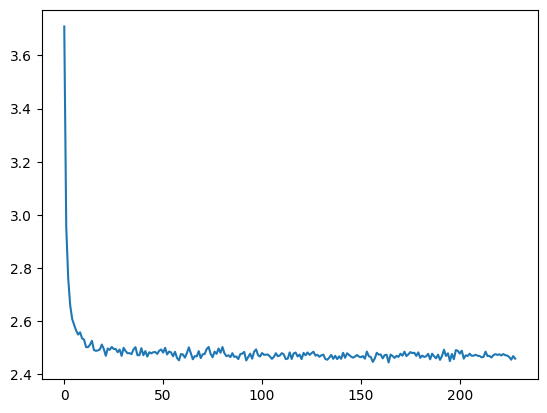

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [7]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

Twhou wh che t'Haleawest hafo hiloumonkewe, bla par hed,
R:
I ike on wnyote;
I befout beret vas, wese.
IAle ant he burioor arren toneves s d hayor s.
Tnor s, beds ot t y fre sthale k sthedive:
ARYothem
----
Therg bto hesh buik we I t this uerofang al ar wat Fegentinco is bl Andy ce t he g ld chiloue st. lod bllo me, ane n, tr k, cero anchad
YCl ke opeeal he s have o m say ld wiveve wnd t par he yaind al yo
----
The s thar beve ha hesard g ar thas t win me anther than hind y mou all in t ou he yo lour I d f hin hall he ononour to a achial urs ce t are ber f whet ke r hy t d prthe ato benoret my we t hor t toure
----
The be t wo t t t the t an an o me s he I ar sour g be my he n he s in to he the n t in t s and he thare y ar me he t are t s men ave h the t he the ar ar t ar t he t t ave the t t me there hathe her ha
----
The the t the t t the the he t s the t t the t t t t t the the t the s t t t t t t the he the t t he t he the he he he t t he t t he t t t the s t the he t he t t the t 

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


In [10]:
# gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## GRU

In [ ]:
#### GRU

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 30 # lower
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 160 # more

####

gru = RNN(n_characters, hidden_size, n_characters, n_layers,rnn_cell=nn.GRU).to(device)
gru_optimizer = torch.optim.Adam(gru.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion


start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(gru,*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss
    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(gru,'Wh', 100), '\n')
    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


plt.figure()
plt.plot(all_losses)

 3s (100 0%) 4.6423]
Wh`z		D}z,4}<M#kh39nVgzU5']T
e~5,*3Bg{xv)I%;$gF`79|8On0|Is&1m
@jNa+Mi/$7{\/X]DU&@(00D~X9$ 

 7s (200 1%) 4.6373]
A"kpKXprfZ<]_sN	%gh%Fk:"D8/S{xm?A<{VtPio!pkQ8Q.l[ g?

 11s (300 1%) 4.6405]
WhfWgt0,#(!$01f=EiWwf0o55Uz95oK~8y\e8}/{~,}&_Cap8a
d|>QjE{2D3oyI2;P?q*^HE;:Tfmmh-*m 

 15s (400 2%) 4.6401]
qdy/rb^ZGir_]-|[&8,%v"RGwQNzMf]$AUb$zQ+'8&f[;~
g.|#_MXBVg`Fc7O6% 

 19s (500 2%) 4.6417]
Wh(gKRR/
A/F ]GW^Jif[%Q},So/<|zL>7r*[=udq7i7b6IfM[Gny3hh()K-c__PsWPNWtb
lE7[,u%@+: 

 23s (600 3%) 4.6400]
LkFQ?	xIJm%nM!	mD}\vz	`=82m	w_h'sJn9U	 ;KK:QHV

 27s (700 3%) 4.6348]
Wh{*BmlH)2?}5U<v8|<O-v0sUP5G#t[0Ipvzb
aUW`u0I$@n-zb	#VYftgz4ACuG&(N?;BZa34Vo^WN<FIcGOs$sT_7>GvKtv9	I] 

 33s (800 4%) 4.6420]
Wh;{]`X<-HQm PoZaFH|'\7+/]L*g(L8<sBaNp;gS!O^LuFKg,SKHjwRy30SjbuG8T_WE_,jp_AP&~#u\TG@GEL LaaSwwV`e 

 38s (900 4%) 4.6421]
Wh1@{_Iv}X;z kAZS	?Q}l5)\r.R2nXwW`vv&e0v'I3R;5-r`\	!]PKQJh(a84%ldg4.omym.GhXE>T6^=E49kl	96;K{P2bFY>u0 

 45s (1000 5%) 4.6416]
Wh_L6<l_K"j{>lFFec
$|xm!'=@%$

KeyboardInterrupt: 

## LSTM

In [ ]:
#### LSTM

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 30 # lower
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 120 # more

####model

lstm = RNN(n_characters, hidden_size, n_characters, n_layers,rnn_cell=nn.LSTM).to(device)
lstm_optimizer = torch.optim.Adam(lstm.parameters(), lr=lr) #create Adam optimizer

criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0

for epoch in range(1, n_epochs + 1):
    loss = train(lstm,*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss
    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(lstm,'Wh', 100), '\n')
    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

plt.figure()
plt.plot(all_losses)


 13s (300 15%) 4.6415]
WhXdg-W#.1"p 2-Tlr,RW?>gak`bxcj/sRnHAuY	LyP?'-LX%,ZJCJqv-,	@D^<g{K5^Qz81Xg*/uTY9v,"2lza9F^rPu8O5LEu 

 19s (400 20%) 4.6364]
Wh)0Ous%L#x0`")l&Ud3uXjz=^=f{V?%BA"8Q^UVlAGp[L+q'GP?3*:,#Dw\vUL0d{T`Sc"
cIkHDJIVrRzcIG| 

 23s (500 25%) 4.6402]
Wh	c`M"
b/5=9nEx<0,E Uvq#?TlY^s	<}&4~&Z|Gq'bw,Q/x "IMX'd=-S'to{MM&,o]FO'q^z

 28s (600 30%) 4.6443]
Wht3hC%
w?\`USN! DHWY\F3@!~$Ifm*BGFP)p"-It4IO:uFufdijOj)o/(FG\.Za 

 31s (700 35%) 4.6423]
BDT[c!a<)LJc-Wo0E8>I,Vqc.EEB!vwNil.y}vEMg#+._,<BeL+.?5# 

 35s (800 40%) 4.6376]
Wh
xT)]zyFP
-Qjbj+C,<wyGv
nxv?AQILJSsuzs^q&	gC3`?KDYcG OXg/c6S%ssS:Tj?i
sg0jzN%,qmmJRW&?azHJDunlKR" 

 38s (900 45%) 4.6425]
WhC!UX	kPQ?=x>0~T6w)j!wqAh3grDK?)>##kT\,R-$?4x
Ae){U?x7w6b_,MC^Tt[XKGU?e	v]a{\UIZ6|_vc,*K#k 

 43s (1000 50%) 4.6425]
WhFZW1r:y[$sZJEt9\aiJm'@xYF\sU`PK*CR$V2_X'!6\h[?5h\;c?*eG{g9<LU|P7Hg#jAKp:il8	2d`qWtF}#:Oo_#5P#u

5! 

 48s (1100 55%) 4.6432]
Wh6!!kP1Eg#cV`: jr6&oI[$GlGr,1QHB"J[Y*l
{#
;TybL
PM7h9d18C8il[8J):c8+1#+ $SqfM38]#